In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv("results_with_direct_answer_annotations_1.csv")
df2 = pd.read_csv("results_with_direct_answer_annotations_3.csv")
df3 = pd.read_csv("results_with_direct_answer_annotations_6.csv")

In [3]:
df1.shape, df2.shape, df1.shape

((8587, 19), (8587, 19), (8587, 19))

In [4]:
def extract_clean_direct_answer(direct_answer):
    direct_answer = str(direct_answer).lower()
    if "yes" in direct_answer:
        return "yes"
    elif "no" in direct_answer:
        return "no"
    else:
        return "error"

In [5]:
df1["sys1_direct_answer"] = df1["sys1_few_shot_response"].apply(
    extract_clean_direct_answer
)
df1["sys2_direct_answer"] = df1["sys2_few_shot_response"].apply(
    extract_clean_direct_answer
)


df1["ability"] = df1["ability"].replace(
    {"math": "Arithmetic", "CS": "Common Sense", "symbolic": "Symbolic"}
)

df2["sys1_direct_answer"] = df2["sys1_few_shot_response"].apply(
    extract_clean_direct_answer
)
df2["sys2_direct_answer"] = df2["sys2_few_shot_response"].apply(
    extract_clean_direct_answer
)


df2["ability"] = df2["ability"].replace(
    {"math": "Arithmetic", "CS": "Common Sense", "symbolic": "Symbolic"}
)

df3["sys1_direct_answer"] = df3["sys1_few_shot_response"].apply(
    extract_clean_direct_answer
)
df3["sys2_direct_answer"] = df3["sys2_few_shot_response"].apply(
    extract_clean_direct_answer
)


df3["ability"] = df3["ability"].replace(
    {"math": "Arithmetic", "CS": "Common Sense", "symbolic": "Symbolic"}
)

In [6]:
df1_clean_first_stage = df1[
    (~df1["sys1_few_shot_response"].isna()) & (~df1["sys2_few_shot_response"].isna())
]
df2_clean_first_stage = df2[
    (~df2["sys1_few_shot_response"].isna()) & (~df2["sys2_few_shot_response"].isna())
]
df3_clean_first_stage = df3[
    (~df3["sys1_few_shot_response"].isna()) & (~df3["sys2_few_shot_response"].isna())
]

In [7]:
df1_clean_first_stage.shape, df2_clean_first_stage.shape, df3_clean_first_stage.shape

((2000, 21), (2000, 21), (2000, 21))

In [8]:
for index in df1_clean_first_stage["index"]:
    assert index in df2_clean_first_stage["index"].values

for index in df2_clean_first_stage["index"]:
    assert index in df1_clean_first_stage["index"].values

for index in df1_clean_first_stage["index"]:
    assert index in df3_clean_first_stage["index"].values

for index in df3_clean_first_stage["index"]:
    assert index in df1_clean_first_stage["index"].values

In [9]:
df1_clean_first_stage.shape, df2_clean_first_stage.shape, df3_clean_first_stage.shape

((2000, 21), (2000, 21), (2000, 21))

In [10]:
indices_union = (
    set(df1_clean_first_stage["index"])
    .union(set(df2_clean_first_stage["index"]))
    .union(set(df3_clean_first_stage["index"]))
)

In [11]:
(df1_clean_first_stage["index"].nunique(), df1_clean_first_stage.shape[0]), (
    df2_clean_first_stage["index"].nunique(),
    df2_clean_first_stage.shape[0],
), (df3_clean_first_stage["index"].nunique(), df3_clean_first_stage.shape[0])

((2000, 2000), (2000, 2000), (2000, 2000))

In [12]:
df1_clean = df1_clean_first_stage.set_index("index")
df2_clean = df2_clean_first_stage.set_index("index")
df3_clean = df3_clean_first_stage.set_index("index")

In [13]:
abilities = []
sys1_answers_1 = []
sys2_answers_1 = []
sys1_answers_3 = []
sys2_answers_3 = []
sys1_answers_6 = []
sys2_answers_6 = []

for index in indices_union:
    data_point_1 = df1_clean.loc[index]
    data_point_2 = df2_clean.loc[index]
    data_point_3 = df3_clean.loc[index]

    sys1_answers_1.append(
        "yes" if data_point_1["sys1_direct_answer"] == "yes" else "no"
    )
    sys2_answers_1.append(
        "yes" if data_point_1["sys2_direct_answer"] == "yes" else "no"
    )

    sys1_answers_3.append(
        "yes"
        if (
            data_point_1["sys1_direct_answer"] == "yes"
            or data_point_2["sys1_direct_answer"] == "yes"
        )
        else "no"
    )
    sys2_answers_3.append(
        "yes"
        if (
            data_point_1["sys2_direct_answer"] == "yes"
            or data_point_2["sys2_direct_answer"] == "yes"
        )
        else "no"
    )

    sys1_answers_6.append(
        "yes"
        if (
            data_point_1["sys1_direct_answer"] == "yes"
            or data_point_2["sys1_direct_answer"] == "yes"
            or data_point_3["sys1_direct_answer"] == "yes"
        )
        else "no"
    )
    sys2_answers_6.append(
        "yes"
        if (
            data_point_1["sys2_direct_answer"] == "yes"
            or data_point_2["sys2_direct_answer"] == "yes"
            or data_point_3["sys2_direct_answer"] == "yes"
        )
        else "no"
    )

    abilities.append(data_point_1["ability"])

merged_df = pd.DataFrame(
    {
        "ability": abilities,
        "sys1_answers_1": sys1_answers_1,
        "sys2_answers_1": sys2_answers_1,
        "sys1_answers_3": sys1_answers_3,
        "sys2_answers_3": sys2_answers_3,
        "sys1_answers_6": sys1_answers_6,
        "sys2_answers_6": sys2_answers_6,
    }
)

In [14]:
merged_df

,ability,sys1_answers_1,sys2_answers_1,sys1_answers_3,sys2_answers_3,sys1_answers_6,sys2_answers_6
0,Arithmetic,no,no,yes,yes,yes,yes
1,Arithmetic,no,yes,yes,yes,yes,yes
2,Symbolic,no,no,no,no,no,no
3,Arithmetic,no,no,no,no,no,yes
4,Arithmetic,no,no,no,yes,no,yes
...,...,...,...,...,...,...,...
1995,Symbolic,yes,no,yes,no,yes,no
1996,Symbolic,no,no,no,no,no,no
1997,Symbolic,yes,no,yes,no,yes,no
1998,Symbolic,no,no,no,no,no,no


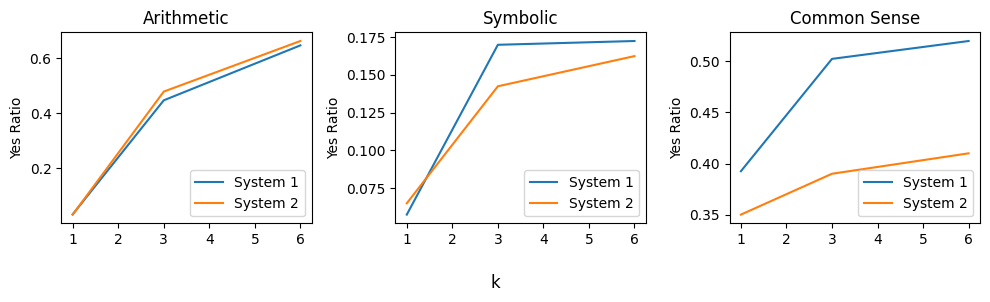

In [17]:
# for each ability, we want to calculate three points, one for each stage, 1, 3, 6
# each point is the ratio of the yes answers to all answers for each system,

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

for ability, ax in zip(merged_df["ability"].unique(), axs):
    ability_df = merged_df[merged_df["ability"] == ability]
    first_stage_yes_ratio_sys1 = (
        ability_df[ability_df["sys1_answers_1"] == "yes"].shape[0] / ability_df.shape[0]
    )
    first_stage_yes_ratio_sys2 = (
        ability_df[ability_df["sys2_answers_1"] == "yes"].shape[0] / ability_df.shape[0]
    )

    second_stage_yes_ratio_sys1 = (
        ability_df[ability_df["sys1_answers_3"] == "yes"].shape[0] / ability_df.shape[0]
    )
    second_stage_yes_ratio_sys2 = (
        ability_df[ability_df["sys2_answers_3"] == "yes"].shape[0] / ability_df.shape[0]
    )

    third_stage_yes_ratio_sys1 = (
        ability_df[ability_df["sys1_answers_6"] == "yes"].shape[0] / ability_df.shape[0]
    )
    third_stage_yes_ratio_sys2 = (
        ability_df[ability_df["sys2_answers_6"] == "yes"].shape[0] / ability_df.shape[0]
    )

    ax.plot(
        [1, 3, 6],
        [
            first_stage_yes_ratio_sys1,
            second_stage_yes_ratio_sys1,
            third_stage_yes_ratio_sys1,
        ],
        label="System 1",
    )
    ax.plot(
        [1, 3, 6],
        [
            first_stage_yes_ratio_sys2,
            second_stage_yes_ratio_sys2,
            third_stage_yes_ratio_sys2,
        ],
        label="System 2",
    )

    ax.set_title(ability)
    # ax.set_xlabel("k")
    ax.set_ylabel("Yes Ratio")
    ax.legend()

fig.supxlabel("k")
plt.tight_layout()
plt.savefig("yes_ratio_across_sentences.png", dpi=300, bbox_inches="tight")
plt.show()